In [1]:
from pdb2mrc import PDB2MRC
from plotting_tools import *
import torch

%load_ext autoreload
%autoreload 2

In [2]:
fftn = lambda array: torch.fft.fftshift(torch.fft.fftn(torch.fft.ifftshift(array)))
ifftn = lambda array: torch.fft.fftshift(torch.fft.ifftn(torch.fft.ifftshift(array)))

## Instantiate class

In [3]:
pdb_code = '6j6j'
pm = PDB2MRC(pdb_code)

## Download PDB file

In [4]:
pm.fetch_pdb()

PDB file saved to: ./pdb-data/6j6j.cif


## Compute particle potential

In [5]:
pm.build_particle(n=200, dx=0.5)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  5.53it/s]


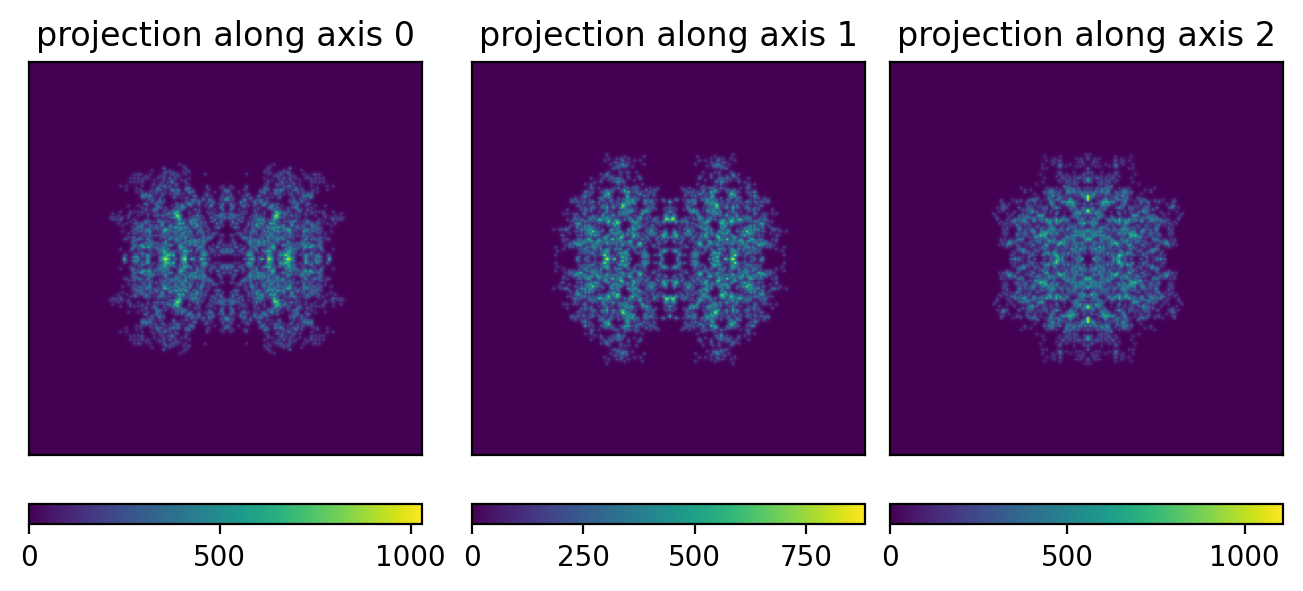

In [7]:
plot3d(pm.particle)

## Solvate
Note: 256A x 256 A x 256A takes 1.5hr. Increases exponentially with larger box sizes.

In [8]:
pm.solvate()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:20<00:00,  4.15s/it]


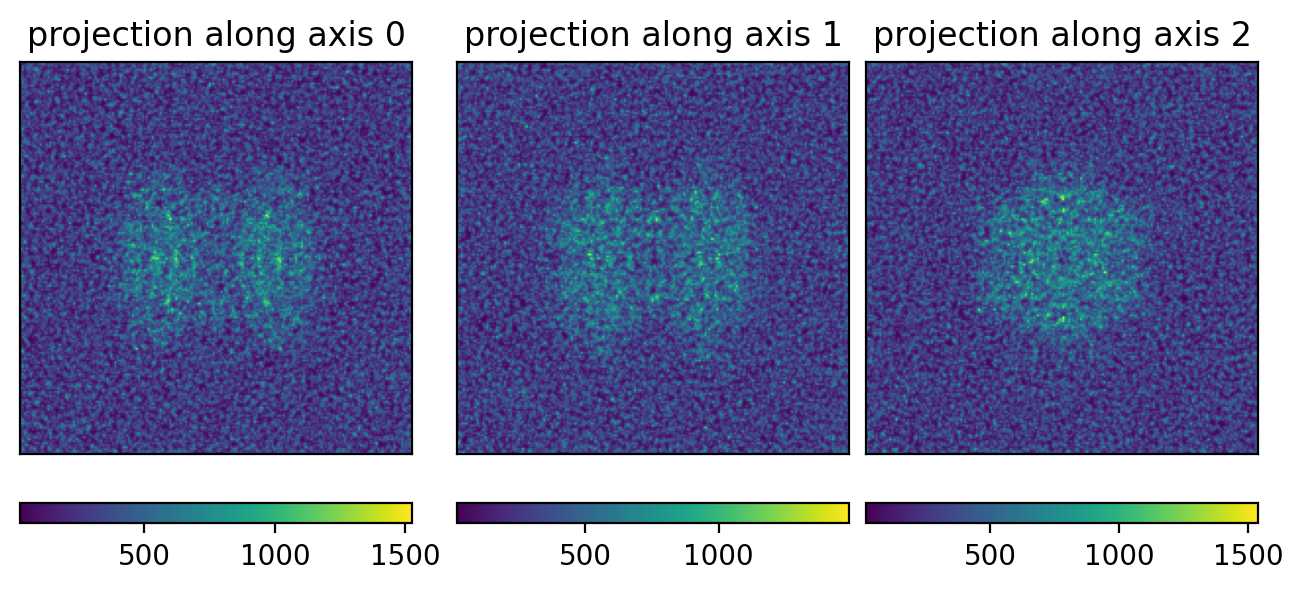

In [9]:
plot3d(pm.icy_particle)

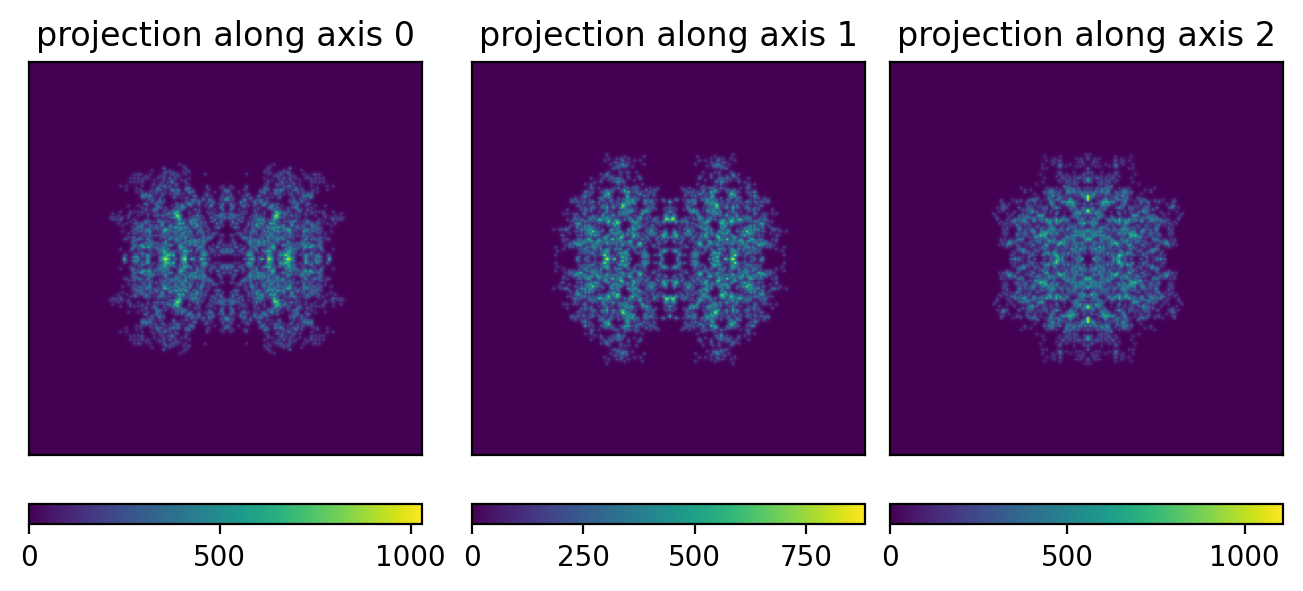

In [10]:
plot3d(pm.particle)

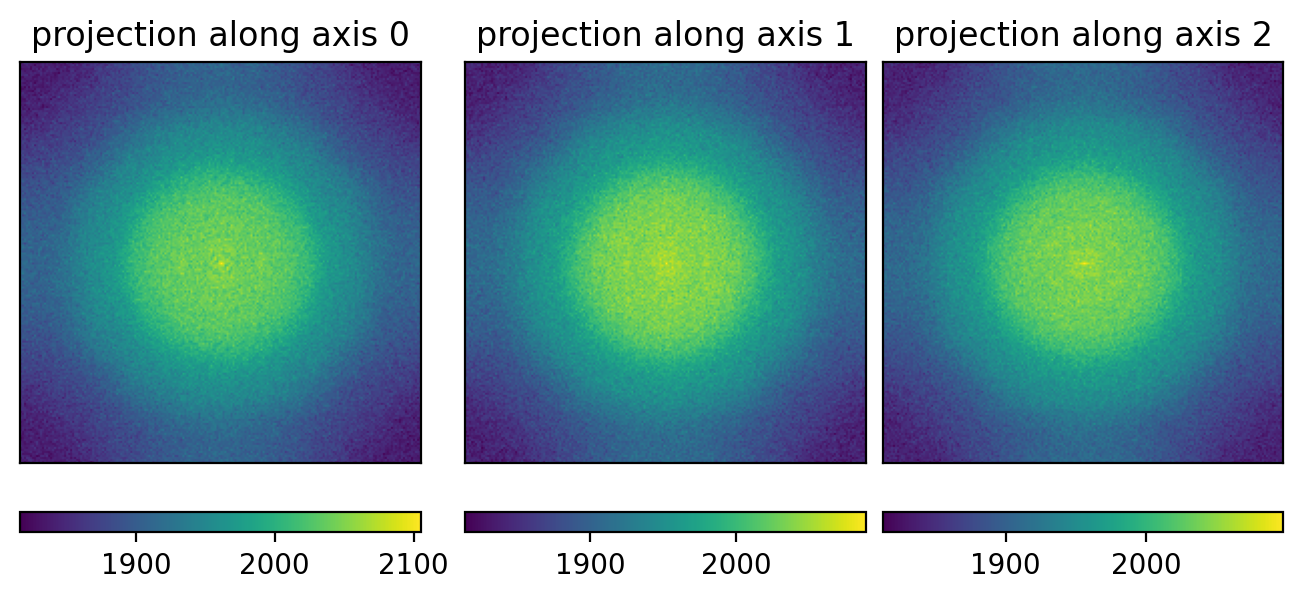

In [11]:
plot3d(torch.log(torch.abs(fftn(pm.icy_particle))))